## **Customer Intelligence System using Classification, Ensemble Learning and Clustering**

The aim of this assignment is to build a Customer Intelligence System using machine learning techniques.

In [150]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [151]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Dataset Information

In [152]:
print("Shape :", df.shape)

df.info()

Shape : (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [153]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [154]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Data Preprocessing

In [155]:
country_names = df['country']

X = df.drop('country', axis=1)
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [156]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


## K-Means Clustering

In [157]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

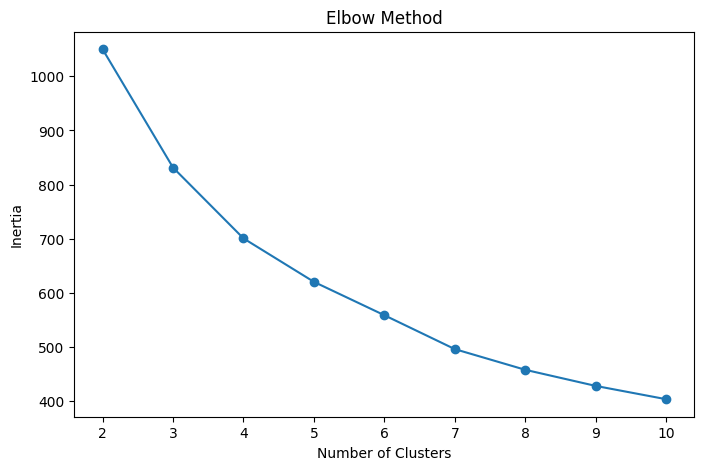

In [158]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [159]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [160]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.28329575683463126


In [161]:
df['Cluster'].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

## PCA Visualization

In [162]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [163]:
plot_df = pd.DataFrame()

plot_df['PC1'] = pca_data[:,0]

plot_df['PC2'] = pca_data[:,1]

plot_df['Cluster'] = clusters

plot_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


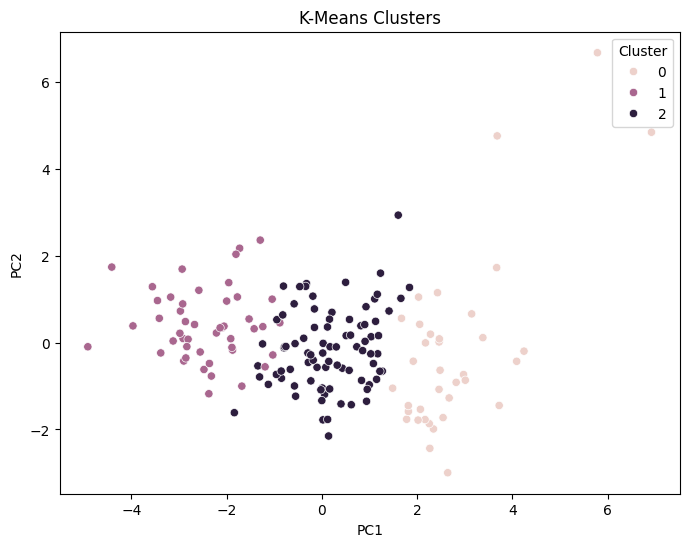

In [164]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster'
)

plt.title("K-Means Clusters")

plt.show()

## DBSCAN Clustering

In [165]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

In [166]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

## Cluster Profiling

In [167]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


In [168]:
for cluster in sorted(df['Cluster'].unique()):

    print("\nCluster", cluster)

    countries = df[df['Cluster']==cluster]['country']

    print(list(countries[:10]))


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']

Cluster 2
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']


## Creating Labels for Classification

In [169]:
X_class = df.drop(
    ['country','Cluster','DBSCAN_Cluster'],
    axis=1
)

y = df['Cluster']

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y,
    test_size=0.20,
    random_state=42
)

## Logistic Regression

In [171]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print("Accuracy :", lr_acc)

Accuracy : 1.0


## Decision Tree

In [172]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test,pred_dt)

print("Accuracy :", dt_acc)

Accuracy : 1.0


## Random Forest

In [173]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print("Accuracy :", rf_acc)

Accuracy : 0.9705882352941176


## XGBoost

In [174]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print("Accuracy :", xgb_acc)

Accuracy : 0.9705882352941176


## Model Comparison

In [175]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
2,Random Forest,0.970588
3,XGBoost,0.970588


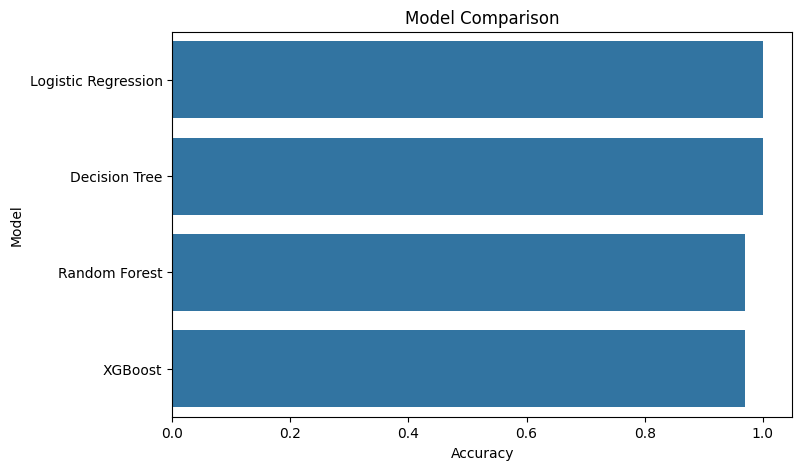

In [176]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Accuracy',
    y='Model'
)

plt.title("Model Comparison")

plt.show()

## Feature Importance

In [177]:
importance = pd.DataFrame({

    'Feature' : X_class.columns,

    'Importance' : rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.276790
8,gdpp,0.194674
4,income,0.167519
6,life_expec,0.157759
7,total_fer,0.141250
2,health,0.024614
5,inflation,0.015699
1,exports,0.013360
3,imports,0.008336


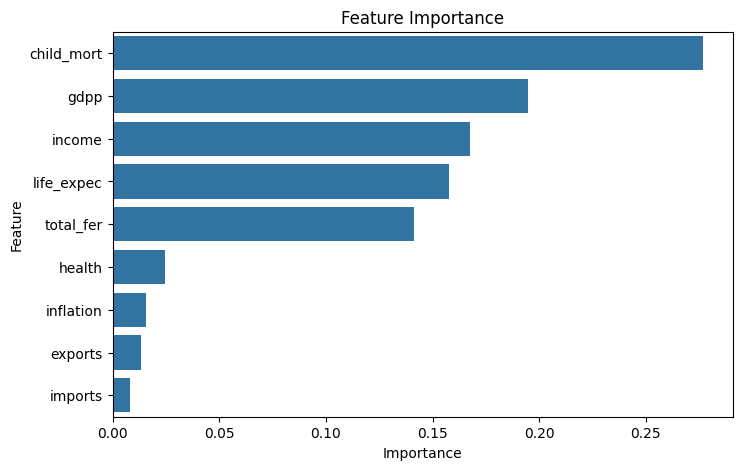

In [178]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

## Evaluation Metrics

In [179]:
print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        pred_rf
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## Evaluation Metrics

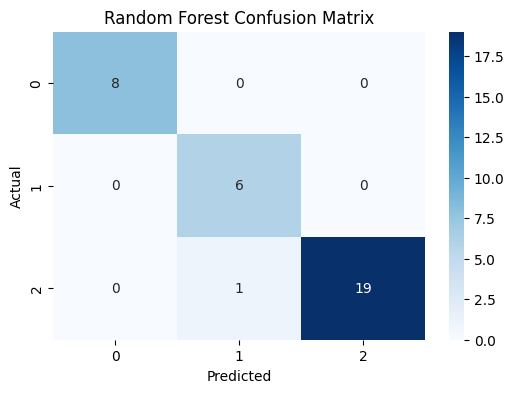

In [180]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Final Insights
1. K-Means successfully segmented countries into different economic groups.

2. Countries with high income, GDP per capita and life expectancy were grouped into the developed-country cluster.

3. Countries with high child mortality and low GDP per capita formed the underdeveloped cluster.

4. DBSCAN helped identify dense groups of similar countries and possible outliers.

5. Random Forest and XGBoost achieved better predictive performance than basic classification models.

6. Income, GDP per capita and child mortality were the most important features influencing segmentation.

7. The developed Customer Intelligence System can help identify countries requiring aid and support decision-making.